# 01 | Refh quality and derived surfaces

This notebook examines the official CASALS L1B reference-height point for each pulse. The H5 `refh_longitude`, `refh_latitude`, and `refh` fields describe the geolocated receiver-waveform maximum. Height is kept as CASALS WGS84 ellipsoidal height. The waveform-derived noise labels, DSM, and tentative DTM below are derived products with separate meanings.

The primary quality sample is the 2024-11-12 granule. The DSM is from a separate 2024-11-18 granule, so the two dates are not a scene-to-scene comparison. All projected maps use EPSG:32618 with metre axes. Product provenance and input paths are checked before display.

## Paths and bounded display settings

Statistics use the H5 records and the saved products as read-only inputs. Map plots use a fixed seeded sample. Product generation is not part of this review run.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import h5py
import laspy
import rasterio
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Run this notebook from the CASALS repository root.")
H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241112T165718_001_02.h5"
DSM_H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
PRODUCT_ROOT = ROOT / "outputs/notebooks/01_refh_quality"  # Existing products are read-only review inputs.
EXPORT_LAS = PRODUCT_ROOT / "export/point_clouds/casals_l1b_20241112T165718_001_02_levelA_refh_epsg32618.las"
FILTER_ROOT = PRODUCT_ROOT / "filter/point_clouds"
FILTER_STEM = "casals_l1b_20241112T165718_001_02"
RAW_LAS = FILTER_ROOT / f"{FILTER_STEM}_raw_refh_epsg32618.las"
NOISE_LAS = FILTER_ROOT / f"{FILTER_STEM}_noise_labeled_refh_epsg32618.las"
CLEAN_LAS = FILTER_ROOT / f"{FILTER_STEM}_clean_refh_epsg32618.las"
DSM_ROOT = PRODUCT_ROOT / "dsm"
DSM_PREFIX = "casals_l1b_20241118T171757_001_02_refh_surface"
DSM_STRICT = DSM_ROOT / f"{DSM_PREFIX}_dsm_strict_snr4p5_2m_epsg32618.tif"
DSM_FILLED = DSM_ROOT / f"{DSM_PREFIX}_dsm_snr4p5_2m_epsg32618.tif"
DSM_SUPPORT = DSM_ROOT / f"{DSM_PREFIX}_support_mask_snr4p5_2m_epsg32618.tif"
GROUND_ROOT = PRODUCT_ROOT / "ground"
GROUND_PREFIX = "casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618"
GROUND_DTM = GROUND_ROOT / f"{GROUND_PREFIX}.tif"
GROUND_SUPPORT = GROUND_ROOT / f"{GROUND_PREFIX}_support_mask.tif"
GROUND_SOURCE = GROUND_ROOT / f"{GROUND_PREFIX}_source_mask.tif"

required = [H5_PATH, DSM_H5_PATH, EXPORT_LAS, RAW_LAS, NOISE_LAS, CLEAN_LAS,
            DSM_STRICT, DSM_FILLED, DSM_SUPPORT, GROUND_DTM, GROUND_SUPPORT, GROUND_SOURCE,
            PRODUCT_ROOT / "export/casals_l1b_20241112T165718_001_02_levelA_refh_metadata.json",
            PRODUCT_ROOT / "filter/casals_l1b_20241112T165718_001_02_filter_metadata.json",
            PRODUCT_ROOT / "dsm/casals_l1b_20241118T171757_001_02_refh_surface_dsm_snr4p5_2m_metadata.json",
            PRODUCT_ROOT / "ground/casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618_metadata.json"]
missing = [path for path in required if not path.exists()]
if missing:
    commands = "\n".join([
        f"python -m casals_l1b refh export --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/export --point-cloud-dir outputs/notebooks/01_refh_quality/export/point_clouds",
        f"python -m casals_l1b refh filter --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/filter --point-cloud-dir outputs/notebooks/01_refh_quality/filter/point_clouds",
        f"python -m casals_l1b refh dsm --h5 {DSM_H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/dsm",
        f"python -m casals_l1b refh ground --h5 {H5_PATH.relative_to(ROOT)} --output-dir outputs/notebooks/01_refh_quality/ground",
    ])
    raise FileNotFoundError("Missing explicit real-data products:\n" + "\n".join(map(str, missing)) + "\n\nGenerate them with:\n" + commands)

MAX_MAP_POINTS = 60_000
RNG_SEED = 42
print(f"H5: {H5_PATH.relative_to(ROOT)}")
print(f"DSM H5: {DSM_H5_PATH.relative_to(ROOT)}")
print(f"Map sample maximum: {MAX_MAP_POINTS:,} (seed={RNG_SEED})")

H5: data\raw\casals_l1b\casals_l1b_20241112T165718_001_02.h5
DSM H5: data\raw\casals_l1b\casals_l1b_20241118T171757_001_02.h5
Map sample maximum: 60,000 (seed=42)


## Full-record quality statistics

The shared H5 reader applies the official Refh validity contract. Counts and medians below are calculated from returned arrays; `good_snr` remains a supplied quality flag and is not equated with the filter's noise class.

In [2]:
from casals_l1b.refh import read_refh_points, project_refh_points
from research.showcase import raster_valid_mask
%matplotlib inline

points = read_refh_points(H5_PATH)
projected = project_refh_points(points)
summary = pd.DataFrame([
    {"measure": "input pulse records", "value": points.n_input_records, "unit": "pulses"},
    {"measure": "valid official refh records", "value": points.n_valid_records, "unit": "pulses"},
    {"measure": "good_snr = true", "value": int(points.good_snr.sum()), "unit": "pulses"},
    {"measure": "good_snr fraction", "value": float(points.good_snr.mean()), "unit": "fraction"},
    {"measure": "refh_snr >= 5", "value": int(np.count_nonzero(points.refh_snr >= 5.0)), "unit": "pulses"},
    {"measure": "refh_snr median", "value": float(np.median(points.refh_snr)), "unit": "dimensionless"},
    {"measure": "refh_amp median", "value": float(np.median(points.refh_amp)), "unit": "raw counts"},
    {"measure": "refh height median", "value": float(np.median(points.z_refh)), "unit": "m, WGS84 ellipsoidal"},
    {"measure": "horizontal CRS", "value": projected.utm_epsg, "unit": "EPSG"},
])
display(summary)
print("Projection round-trip maximum horizontal error (m):",
      projected.projection_check.get("approx_max_horizontal_error_m"))

,measure,value,unit
0,input pulse records,3.604480e+06,pulses
1,valid official refh records,3.604480e+06,pulses
2,good_snr = true,4.274000e+04,pulses
3,good_snr fraction,1.185747e-02,fraction
4,refh_snr >= 5,4.274000e+04,pulses
5,refh_snr median,1.997472e+00,dimensionless
6,refh_amp median,5.360000e+02,raw counts
7,refh height median,-2.550444e+01,"m, WGS84 ellipsoidal"
8,horizontal CRS,3.261800e+04,EPSG


Projection round-trip maximum horizontal error (m): 2.3729285203444306e-09


## Official Refh footprint and signal distributions

The plotted points are a deterministic sample of the complete official Refh footprint. Color limits use finite 2nd and 98th percentiles; the plotted values are also masked to finite records.

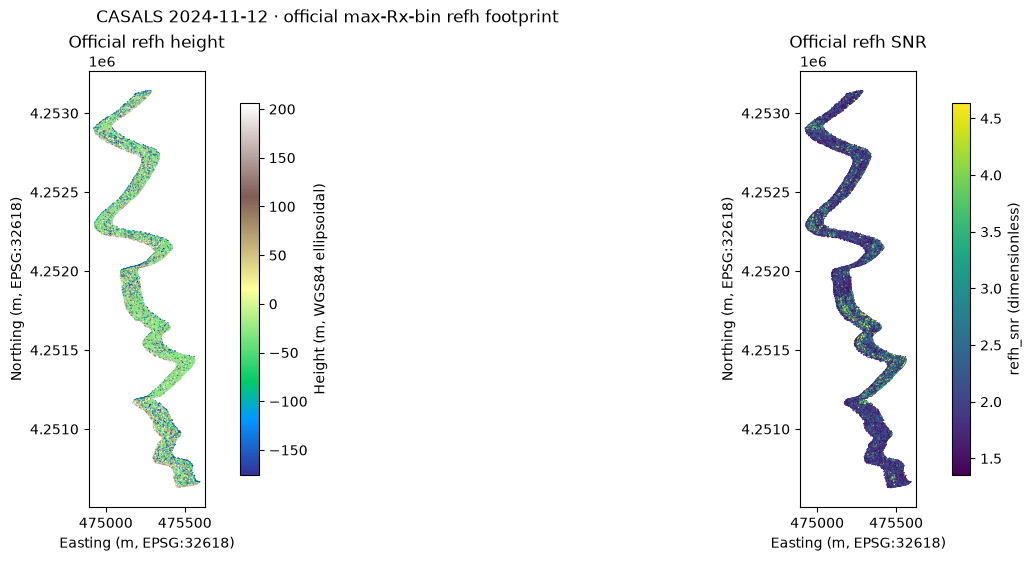

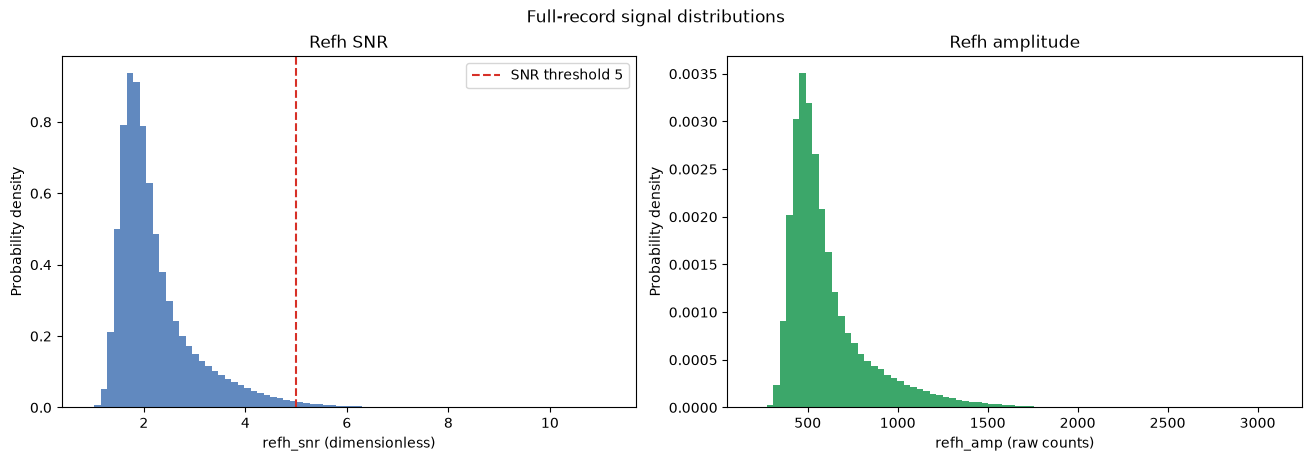

In [3]:
rng = np.random.default_rng(RNG_SEED)
plot_idx = rng.choice(points.n_valid_records, size=min(MAX_MAP_POINTS, points.n_valid_records), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
for ax, values, title, label, cmap in [
    (axes[0], points.z_refh, "Official refh height", "Height (m, WGS84 ellipsoidal)", "terrain"),
    (axes[1], points.refh_snr, "Official refh SNR", "refh_snr (dimensionless)", "viridis"),
]:
    valid_values = np.isfinite(values)
    lo, hi = np.percentile(values[valid_values], [2, 98])
    selected = plot_idx[valid_values[plot_idx]]
    sc = ax.scatter(projected.easting[selected], projected.northing[selected],
                    c=values[selected], s=1.0, cmap=cmap, vmin=lo, vmax=hi,
                    linewidths=0, rasterized=True)
    ax.set_title(title)
    ax.set_xlabel("Easting (m, EPSG:32618)")
    ax.set_ylabel("Northing (m, EPSG:32618)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label=label, shrink=0.85)
fig.suptitle("CASALS 2024-11-12 · official max-Rx-bin refh footprint")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].hist(points.refh_snr, bins=80, density=True, color="#4575b4", alpha=0.85)
axes[0].axvline(5, color="#d73027", linestyle="--", label="SNR threshold 5")
axes[0].set(xlabel="refh_snr (dimensionless)", ylabel="Probability density", title="Refh SNR")
axes[0].legend()
axes[1].hist(points.refh_amp, bins=80, density=True, color="#1a9850", alpha=0.85)
axes[1].set(xlabel="refh_amp (raw counts)", ylabel="Probability density", title="Refh amplitude")
fig.suptitle("Full-record signal distributions")
plt.show()

## Raw, noise-labeled, and clean products

The table reports actual point and class counts from each saved LAS. Pulse identity and source-H5 provenance are checked against the current full-record input before comparing the three product stages.

,product,points,class counts,CRS EPSG,unique pulse_index
0,raw selected,42740,{1: 42740},32618,42740
1,noise-labeled,42740,{1: 42740},32618,42740
2,clean,42740,{1: 42740},32618,42740


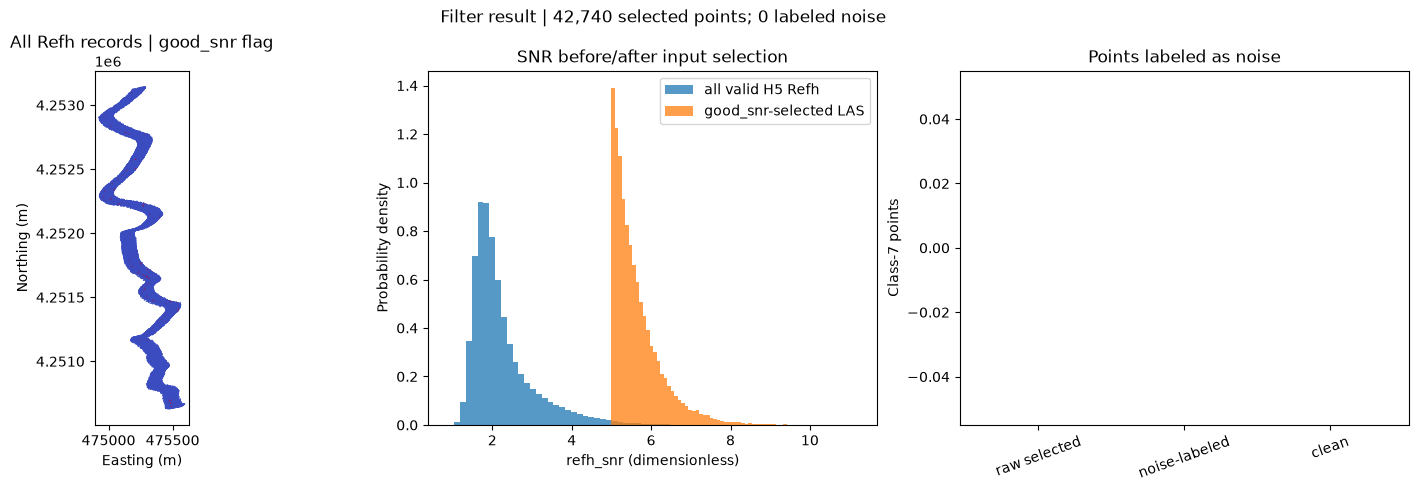

Good-SNR H5 rows: 42740 | noise-class removals: 0


In [4]:
metadata_paths = {
    "export": PRODUCT_ROOT / "export/casals_l1b_20241112T165718_001_02_levelA_refh_metadata.json",
    "filter": PRODUCT_ROOT / "filter/casals_l1b_20241112T165718_001_02_filter_metadata.json",
}
product_metadata = {name: json.loads(path.read_text(encoding="utf-8")) for name, path in metadata_paths.items()}
assert Path(product_metadata["export"]["source_h5"]).resolve() == H5_PATH.resolve()
assert Path(product_metadata["filter"]["source_h5"]).resolve() == H5_PATH.resolve()
expected_pulse_index = points.pulse_index[points.good_snr].astype(np.uint32)
las_raw, las_noise, las_clean = (laspy.read(path) for path in (RAW_LAS, NOISE_LAS, CLEAN_LAS))
las_summary = []
for label, las in [("raw selected", las_raw), ("noise-labeled", las_noise), ("clean", las_clean)]:
    values, counts = np.unique(np.asarray(las.classification, dtype=np.uint8), return_counts=True)
    class_counts = {int(k): int(v) for k, v in zip(values, counts)}
    assert "pulse_index" in las.point_format.extra_dimension_names
    pulse_index = np.asarray(las.pulse_index, dtype=np.uint32)
    assert np.array_equal(pulse_index, expected_pulse_index), f"{label} point identity/order differs from good_snr H5 rows"
    assert las.header.point_count == len(expected_pulse_index)
    assert las.header.parse_crs() is not None and las.header.parse_crs().to_epsg() == 32618
    las_summary.append({"product": label, "points": int(las.header.point_count),
                        "class counts": class_counts, "CRS EPSG": las.header.parse_crs().to_epsg(),
                        "unique pulse_index": int(np.unique(pulse_index).size)})
display(pd.DataFrame(las_summary))

all_keep = points.good_snr
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
axes[0].scatter(projected.easting[plot_idx], projected.northing[plot_idx],
                c=all_keep[plot_idx].astype(int), s=0.8, cmap="coolwarm", vmin=0, vmax=1,
                linewidths=0, rasterized=True)
axes[0].set(title="All Refh records | good_snr flag", xlabel="Easting (m)", ylabel="Northing (m)")
axes[0].set_aspect("equal", adjustable="box")
axes[1].hist(points.refh_snr, bins=70, density=True, alpha=.75, label="all valid H5 Refh")
axes[1].hist(np.asarray(las_raw.refh_snr), bins=70, density=True, alpha=.75, label="good_snr-selected LAS")
axes[1].set(title="SNR before/after input selection", xlabel="refh_snr (dimensionless)", ylabel="Probability density")
axes[1].legend()
labels = ["raw selected", "noise-labeled", "clean"]
noise_counts = [int(np.count_nonzero(np.asarray(l.classification) == 7)) for l in (las_raw, las_noise, las_clean)]
axes[2].bar(labels, noise_counts, color=["#777777", "#d73027", "#1a9850"])
axes[2].set(title="Points labeled as noise", ylabel="Class-7 points")
axes[2].tick_params(axis="x", rotation=20)
selected_count = int(las_raw.header.point_count)
noise_total = int(noise_counts[-1])
fig.suptitle(f"Filter result | {selected_count:,} selected points; {noise_total:,} labeled noise")
plt.show()

assert np.array_equal(las_raw.pulse_index, las_noise.pulse_index)
assert np.array_equal(las_raw.pulse_index, las_clean.pulse_index)
print("Good-SNR H5 rows:", len(expected_pulse_index), "| noise-class removals:", noise_total)

## Surface products: DSM and tentative DTM

The 2024-11-18 DSM and 2024-11-12 tentative DTM are different acquisitions and different products. Statistics and display masks below exclude nodata, NaN, and infinite cells; DSM values are additionally limited to valid support. The DTM remains a tentative ground-candidate surface, not a certified ground model.

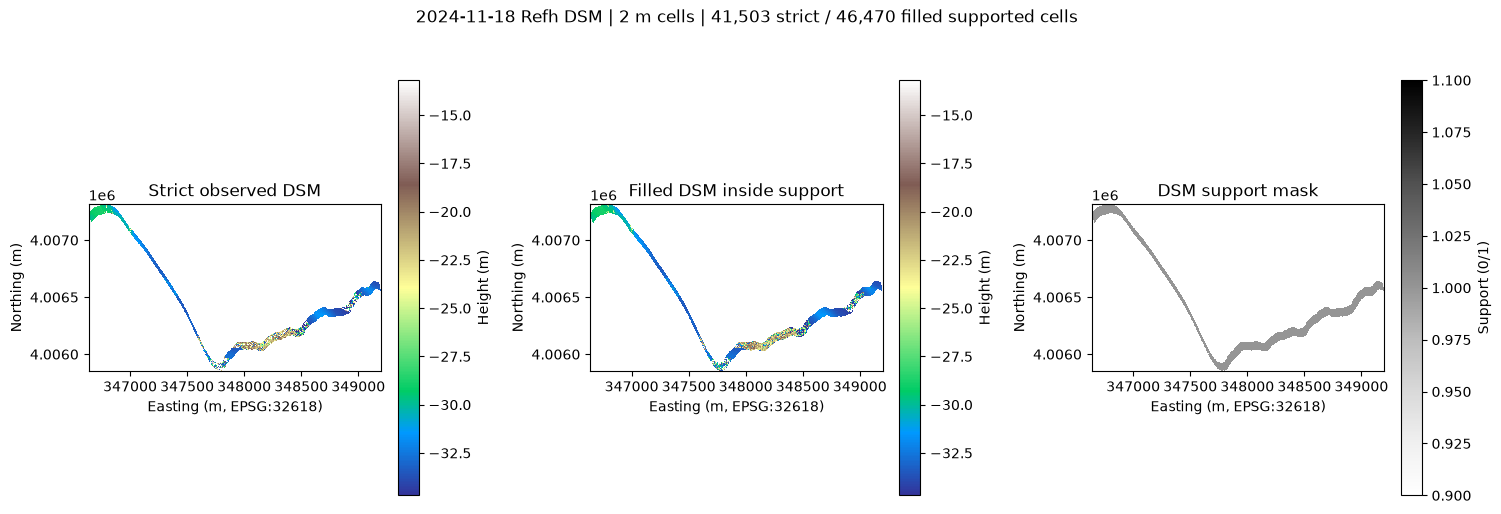

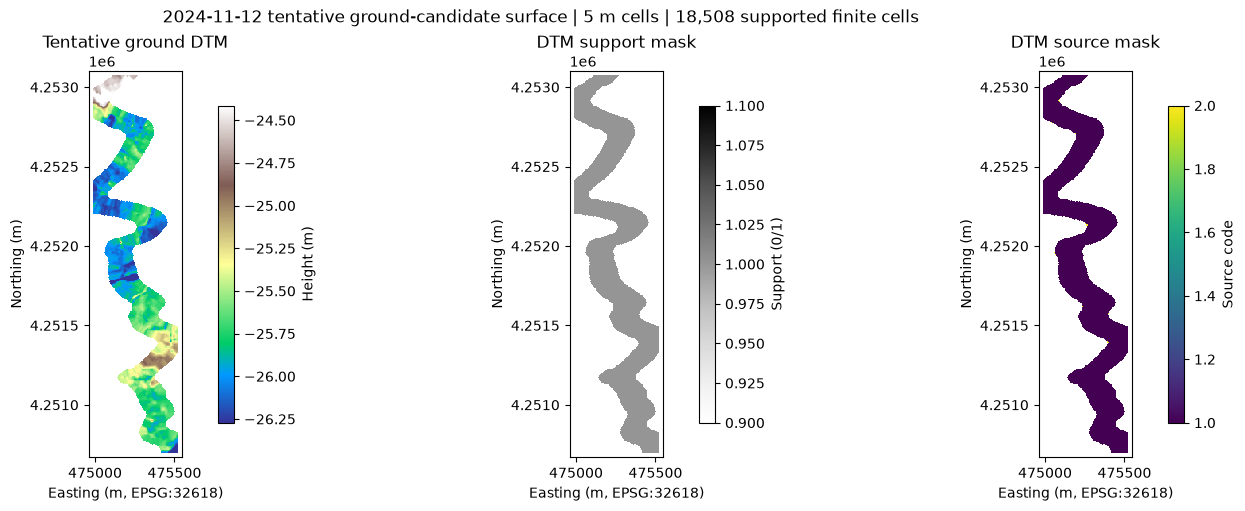

DSM valid counts: {'strict': 41503, 'filled_supported': 46470}
DTM support counts: {'finite_supported': 18508, 'support_cells': 18508}


In [5]:
from rasterio.transform import Affine
from rasterio.crs import CRS

def raster_data(path):
    with rasterio.open(path) as ds:
        return {"array": ds.read(1), "profile": ds.profile.copy(), "bounds": ds.bounds,
                "crs": ds.crs, "nodata": ds.nodata, "transform": ds.transform,
                "resolution": ds.res}

def assert_same_grid(named_rasters):
    reference = named_rasters[0][1]
    for name, raster in named_rasters[1:]:
        assert raster["array"].shape == reference["array"].shape, f"{name} shape differs"
        assert raster["crs"] == reference["crs"], f"{name} CRS differs"
        assert raster["transform"] == reference["transform"], f"{name} affine transform differs"

strict_raster = raster_data(DSM_STRICT)
filled_raster = raster_data(DSM_FILLED)
support_raster = raster_data(DSM_SUPPORT)
assert_same_grid([("filled DSM", filled_raster), ("support", support_raster)])
assert strict_raster["array"].shape == filled_raster["array"].shape
assert strict_raster["crs"] == filled_raster["crs"] and strict_raster["transform"] == filled_raster["transform"]
assert strict_raster["crs"].to_epsg() == 32618
assert np.allclose(strict_raster["resolution"], (2.0, 2.0))
strict, filled, support = strict_raster["array"], filled_raster["array"], support_raster["array"]
dsm_support_valid = raster_valid_mask(support, support_raster["nodata"])
strict_valid = raster_valid_mask(strict, strict_raster["nodata"], support=dsm_support_valid)
filled_valid = raster_valid_mask(filled, filled_raster["nodata"], support=dsm_support_valid)
if not strict_valid.any() or not filled_valid.any():
    raise RuntimeError("DSM has no finite, supported cells for statistics.")
shared_dsm_values = np.concatenate([strict[strict_valid], filled[filled_valid]])
lo, hi = np.percentile(shared_dsm_values, [2, 98])
bounds = strict_raster["bounds"]
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), constrained_layout=True)
for ax, values, mask, title, cmap in [
    (axes[0], strict, strict_valid, "Strict observed DSM", "terrain"),
    (axes[1], filled, filled_valid, "Filled DSM inside support", "terrain"),
    (axes[2], support, dsm_support_valid, "DSM support mask", "Greys"),
]:
    shown = np.ma.masked_where(~mask, values)
    is_mask = "mask" in title.lower()
    im = ax.imshow(shown, extent=extent, origin="upper", cmap=cmap,
                   vmin=None if is_mask else lo, vmax=None if is_mask else hi,
                   interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel(f"Easting (m, {strict_raster['crs'].to_string()})")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(im, ax=ax, label="Support (0/1)" if is_mask else "Height (m)", shrink=0.82)
fig.suptitle(f"2024-11-18 Refh DSM | 2 m cells | {strict_valid.sum():,} strict / {filled_valid.sum():,} filled supported cells")
plt.show()

# Read-only provenance and grid checks for the DSM and tentative DTM.
dsm_metadata_path = PRODUCT_ROOT / "dsm/casals_l1b_20241118T171757_001_02_refh_surface_dsm_snr4p5_2m_metadata.json"
dtm_metadata_path = PRODUCT_ROOT / "ground/casals_l1b_20241112T165718_001_02_tentative_ground_idw_filled_snr5_5m_epsg32618_metadata.json"
dsm_metadata = json.loads(dsm_metadata_path.read_text(encoding="utf-8"))
dtm_metadata = json.loads(dtm_metadata_path.read_text(encoding="utf-8"))
assert Path(dsm_metadata["source_h5"]).resolve() == DSM_H5_PATH.resolve()
assert Path(dtm_metadata["source_h5"]).resolve() == H5_PATH.resolve()

dtm_raster = raster_data(GROUND_DTM)
dtm_support_raster = raster_data(GROUND_SUPPORT)
dtm_source_raster = raster_data(GROUND_SOURCE)
assert_same_grid([("DTM support", dtm_support_raster), ("DTM source", dtm_source_raster)])
assert dtm_raster["array"].shape == dtm_support_raster["array"].shape
assert dtm_raster["crs"] == dtm_support_raster["crs"] and dtm_raster["transform"] == dtm_support_raster["transform"]
assert dtm_raster["crs"].to_epsg() == 32618
assert np.allclose(dtm_raster["resolution"], (5.0, 5.0))
DTM, DTM_SUPPORT, DTM_SOURCE = dtm_raster["array"], dtm_support_raster["array"], dtm_source_raster["array"]
dtm_support_valid = raster_valid_mask(DTM_SUPPORT, dtm_support_raster["nodata"])
dtm_valid = raster_valid_mask(DTM, dtm_raster["nodata"], support=dtm_support_valid)
if not dtm_valid.any():
    raise RuntimeError("Tentative DTM has no finite, supported cells for statistics.")
dtm_lo, dtm_hi = np.percentile(DTM[dtm_valid], [2, 98])
dtm_bounds = dtm_raster["bounds"]
dtm_extent = [dtm_bounds.left, dtm_bounds.right, dtm_bounds.bottom, dtm_bounds.top]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)
for ax, arr, valid_mask, title, cmap, lab in [
    (axes[0], DTM, dtm_valid, "Tentative ground DTM", "terrain", "Height (m)"),
    (axes[1], DTM_SUPPORT, dtm_support_valid, "DTM support mask", "Greys", "Support (0/1)"),
    (axes[2], DTM_SOURCE, raster_valid_mask(DTM_SOURCE, dtm_source_raster["nodata"]), "DTM source mask", "viridis", "Source code"),
]:
    shown = np.ma.masked_where(~valid_mask, arr)
    is_mask = "mask" in title.lower()
    im = ax.imshow(shown, extent=dtm_extent, origin="upper", cmap=cmap,
                   vmin=None if is_mask else dtm_lo, vmax=None if is_mask else dtm_hi,
                   interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel(f"Easting (m, {dtm_raster['crs'].to_string()})")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(im, ax=ax, label=lab, shrink=0.82)
fig.suptitle(f"2024-11-12 tentative ground-candidate surface | 5 m cells | {int(dtm_valid.sum()):,} supported finite cells")
plt.show()
print("DSM valid counts:", {"strict": int(strict_valid.sum()), "filled_supported": int(filled_valid.sum())})
print("DTM support counts:", {"finite_supported": int(dtm_valid.sum()), "support_cells": int(dtm_support_valid.sum())})

## Interpretation and limits

- Official Refh is the CASALS max-RX-bin georeference. It is not a discrete multi-return point cloud.
- `good_snr` is a supplied H5 quality flag. The filter's point and class counts are read from saved LAS files and checked against their pulse indices.
- The DSM and tentative DTM use different granules and different grid resolutions. Nodata, nonfinite cells, and cells outside support are excluded from raster statistics and display.
- The DTM is a tentative derived surface, not a certified ground model. Elevations remain CASALS/Refh-derived; neither the projected CRS nor the 3DEP comparison converts them to an orthometric datum.